In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import h5py
import os
from glob import glob
from scipy.signal import find_peaks
from scipy.optimize import curve_fit

def gaussian_log(tau, A, tau0, sigma):
    return A * np.exp(-((np.log10(tau) - np.log10(tau0))**2)/(2*sigma**2))


s321 = {'name' : '321', 'comp' : '30 Ir 30 C'}
MEA = [s321]

for mea in MEA:
    mea['folder']= glob(os.path.join(r'//ELECTROLYZER/PEM-WE_measurements/2026/AEM-WE/'+'*'+mea['name']+'*/PROCESSED_EIS'))[0]
    # mea['folder']= glob(os.path.join(r'//octavo.troja.mff.cuni.cz/PEM-WE/PEM_WE_research_new_PC/2026/'+mea['name']+'*/PROCESSED_EIS'))[0]
    # mea['folder']= glob(os.path.join(r'//ELECTROLYZER/PEM-WE_measurements/2024_new_naming/'+'*'+mea['name']+'*/'))[0]
    # mea['files'] =  glob(os.path.join(mea['folder'][0],'*rocedur*'+'*PEIS*'+'*.mpt'))
    # folder = r"C:/Users/Herman/Desktop/"
    # print(mea['folder'])
    # mea['files'] =  glob(os.path.join(mea['folder'],'*batch2_3_batch1_interruptions_*'+'*PEIS_C01.mpt'))
    mea['files'] =  glob(os.path.join(mea['folder'],'*.h5'))

def load_spectra_h5(filename):
    spectra = []
    metadata_list = []
    impedance = []

    with h5py.File(filename, "r") as f:
        for name in f:
            grp = f[name]
            # print(grp["DRT data/tau (s)"])
            spectra.append(np.array([grp["DRT data/tau (s)"][:],grp["DRT data/gamma"]]).T)
            try:
                impedance.append(np.array([grp["EIS data/Re(Z) (Ohm)"][:],grp["EIS data/-Im(Z) (Ohm)"]]).T)
            except:
                impedance.append(np.array([grp["EIS data/Re(Zwe-ce) (Ohm)"][:],grp["EIS data/-Im(Zwe-ce) (Ohm)"]]).T)
                # impedance.append(np.array(grp["impedance"][:]))
            # value = grp["value"][:]
            # spectra.append((energy, value))
            metadata_list.append(dict(grp['DRT data'].attrs))
            # print(metadata_list)
    f.close()
    # return spectra, impedance, metadata_list
    return spectra, impedance, metadata_list

def multi_gaussian(tau, *params):
    # params: [A1, tau1, sigma1, A2, tau2, sigma2, ...]
    y = np.zeros_like(tau)
    for i in range(0, len(params), 3):
        A = params[i]
        tau0 = params[i+1]
        sigma = params[i+2]
        y += A * np.exp(-((np.log10(tau) - np.log10(tau0))**2)/(2*sigma**2))
    return y

def drt_to_impedance(tau, gamma, freq, R_inf=0.0, L = 0):
    """
    Convert DRT spectrum to complex impedance.

    Parameters
    ----------
    tau : array_like
        Relaxation times (s), log-spaced
    gamma : array_like
        DRT values (Ohm)
    freq : array_like
        Frequencies (Hz)
    R_inf : float, optional
        High-frequency resistance (Ohm)

    Returns
    -------
    Z : ndarray
        Complex impedance at each frequency
    """
    omega = 2 * np.pi * freq
    ln_tau = np.log(tau)

    Z = np.zeros(len(freq), dtype=complex)

    for i, w in enumerate(omega):
        kernel = gamma / (1 + 1j * w * tau)
        Z[i] = R_inf + 1j*w*L+ np.trapz(kernel, ln_tau)

    return Z


# s321 = {'name' : '321', 'comp' : '30 Ir 30 C'}
# MEA = [s321]

# for mea in MEA:
#     # mea['folder']= glob(os.path.join(r'//ELECTROLYZER/PEM-WE_measurements/2026/'+'*'+mea['name']+'*/'))[0]
#     mea['folder']= glob(os.path.join(r'//ELECTROLYZER/PEM-WE_measurements/2026/AEM/'+mea['name']+'*/PROCESSED_EIS'))[0]
#     # mea['folder']= glob(os.path.join(r'//ELECTROLYZER/PEM-WE_measurements/2024_new_naming/'+'*'+mea['name']+'*/'))[0]
#     # mea['files'] =  glob(os.path.join(mea['folder'][0],'*rocedur*'+'*PEIS*'+'*.mpt'))
#     # folder = r"C:/Users/Herman/Desktop/"
#     print(mea['folder'])
#     # mea['files'] =  glob(os.path.join(mea['folder'],'*batch2_3_batch1_interruptions_*'+'*PEIS_C01.mpt'))
#     mea['files'] =  glob(os.path.join(mea['folder'],'*.h5'))
#     print(mea['files'])
# filename = r'\\ELECTROLYZER\PEM-WE_measurements\2026\AEM\321_VI_VII 120 nm Ni83 Fe17 on piperion pplane, activated after sputtering, RDC 957\PROCESSED_EIS\\VI_Day1_Procedure1_05_PEIS_C01.h5'
# filename = r'\\ELECTROLYZER\PEM-WE_measurements\2026\319_VII_VII Racek_2026_3, 14Ar1O2, GDE\PROCESSED_EIS\VII_Day10_procedure1_05_PEIS_C01_DRT.h5'
# print(load_spectra_h5(r'\\ELECTROLYZER\PEM-WE_measurements\2026\319_VII_VII Racek_2026_3, 14Ar1O2, GDE\PROCESSED_EIS\VII_Day1_procedure1_05_PEIS_C01_DRT.h5'))
# filename = mea['files'][0]
# f = h5py.File(filename, "r") 
# print(f)
# print(f['spectrum_005']["spectrum"])
# print(load_spectra_h5(r'\\ELECTROLYZER\PEM-WE_measurements\2026\319_VII_VII Racek_2026_3, 14Ar1O2, GDE\PROCESSED_EIS\VII_Day1_procedure1_05_PEIS_C01_DRT.h5'))



In [10]:
def assign_peak_ids_with_height(new_taus, new_heights,
                                ref_taus, ref_heights, ref_ids,
                                log_tau_tol=0.4, height_ratio_tol=0.4):

    ref_logtau = np.log10(ref_taus)
    assigned_ids = []
    used_ref = set()

    for tau, h in zip(new_taus, new_heights):
        logtau = np.log10(tau)
        distances = np.abs(ref_logtau - logtau)
        candidate_idxs = np.argsort(distances)

        assigned = None
        for idx in candidate_idxs:
            if idx in used_ref:
                continue
            if distances[idx] > log_tau_tol:
                break

            h_ref = ref_heights[idx]
            height_ratio = h / h_ref
            if (1 - height_ratio_tol) <= height_ratio <= (1 + height_ratio_tol):
                assigned = ref_ids[idx]
                used_ref.add(idx)
                break

        assigned_ids.append(assigned)

    return assigned_ids

def peak_assignment(filename,df):
    df = df.copy()
    df["assigned_peak_id"] = np.nan

    # Sort spectra in reverse order (start from last)
    spectrum_ids = sorted(df["spectrum_id"].unique(), reverse=True)

    # Initialize reference from the last spectrum
    ref_sid = spectrum_ids[0]
    ref = df[df["spectrum_id"] == ref_sid].copy()
    ref["assigned_peak_id"] = ref["peak_id"]

    df.loc[ref.index, "assigned_peak_id"] = ref["assigned_peak_id"]

    next_new_id = df["peak_id"].max() + 1

    
    name = str(ref["spectrum_name"].values[0] )
    with h5py.File(file, "a") as f:
        if 'assigned_peak_id' in f[name]['DRT peaks']:
            f[name]['DRT peaks/assigned_peak_id'][:] = ref["assigned_peak_id"].values 
        else:
            f[name]['DRT peaks'].create_dataset('assigned_peak_id',data = ref["assigned_peak_id"].values )
    
    
    
    # Loop over remaining spectra
    for sid in spectrum_ids[1:]:
        current = df[df["spectrum_id"] == sid].copy()

        assigned = assign_peak_ids_with_height(
            current["tau"].values,
            current["amplitude"].values,
            ref["tau"].values,
            ref["amplitude"].values,
            ref["assigned_peak_id"].values,
            log_tau_tol=0.7,
            height_ratio_tol=1
        )

        # Assign matched or new IDs
        new_ids = []
        for pid in assigned:
            if pid is None:
                new_ids.append(next_new_id)
                next_new_id += 1
            else:
                new_ids.append(pid)

        current["assigned_peak_id"] = new_ids
        df.loc[current.index, "assigned_peak_id"] = current["assigned_peak_id"]
        
        name = str(current["spectrum_name"].values[0])
        # print(name)
        # print(new_ids)
        # Update reference to this spectrum
        ref = current.copy()
        
        with h5py.File(file, "a") as f:
            if 'assigned_peak_id' in f[name]['DRT peaks']:
                f[name]['DRT peaks/assigned_peak_id'][:] = new_ids
            else:
                f[name]['DRT peaks'].create_dataset('assigned_peak_id',data = new_ids)
#             for spectrum in f:
#                 # print(spectrum)
#                 drt_peaks = f[spectrum]['DRT peaks']
#                 # spec_grp = spectra_grp[spec_name]

#                 df_spec = pd.DataFrame({col: drt_peaks[col][()] for col in drt_peaks.keys()})

#                 # Add attributes
#                 for key, value in drt_peaks.attrs.items():
#                     df_spec[key] = value

#                 rows.append(df_spec)

//ELECTROLYZER/PEM-WE_measurements/2026/AEM-WE\321_VI_VII 120 nm Ni83 Fe17 on piperion pplane, activated after sputtering, RDC 957\PROCESSED_EIS\VI_Day1_Procedure1_05_PEIS_C01_DRT.h5
<class 'numpy.ndarray'>


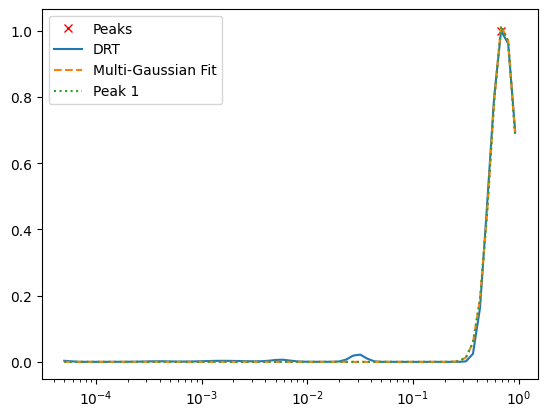

Spectrum 1/60 successfully analyzed!


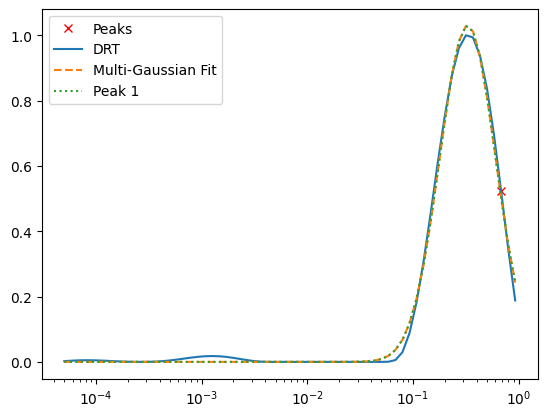

Spectrum 2/60 successfully analyzed!


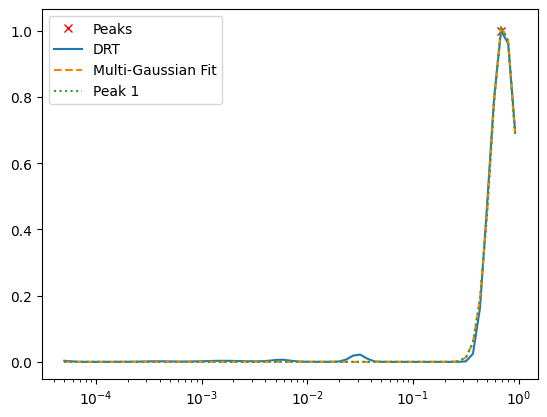

Spectrum 3/60 successfully analyzed!


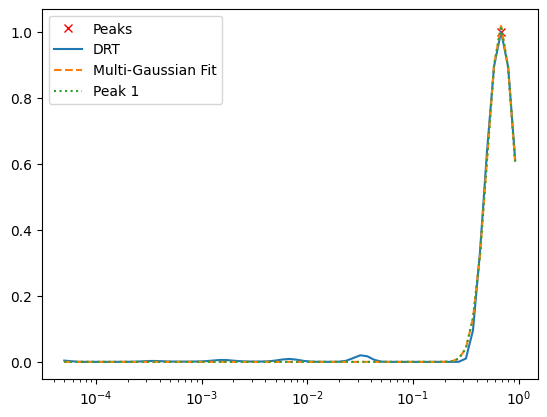

Spectrum 4/60 successfully analyzed!


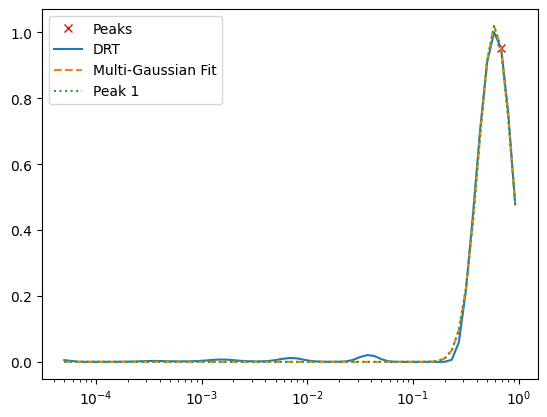

Spectrum 5/60 successfully analyzed!


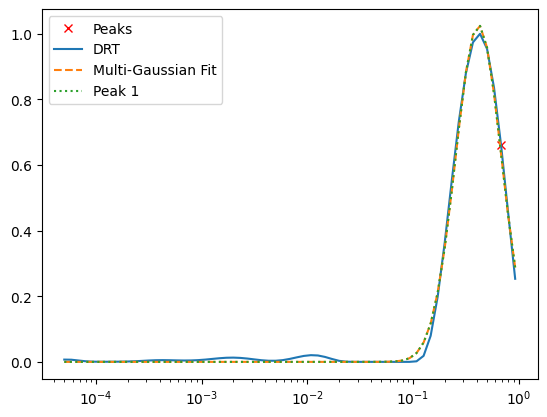

Spectrum 6/60 successfully analyzed!


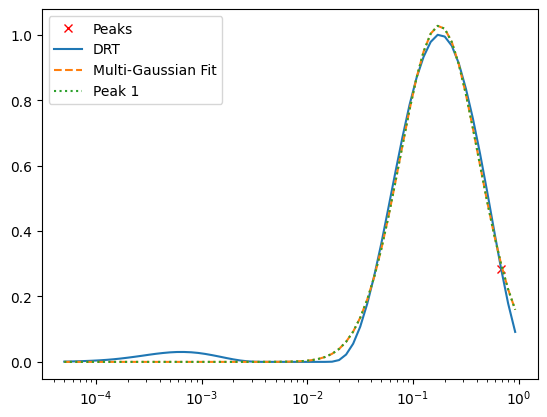

Spectrum 7/60 successfully analyzed!


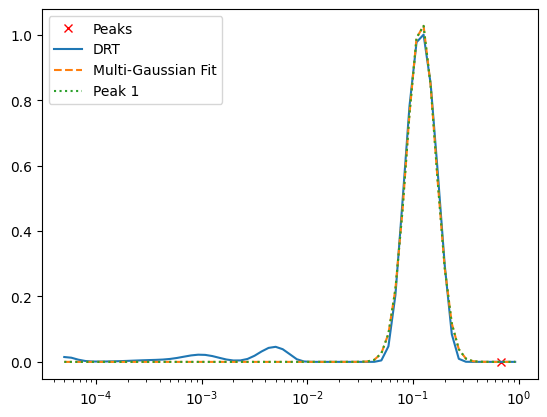

Spectrum 8/60 successfully analyzed!


IndexError: index 62 is out of bounds for axis 0 with size 58

In [18]:
# for file in mea['files'][0:1]:
#     print(file)
#     spectra, metadata, groups = load_spectra_h5(file)
    
#     spectrum_id = 1 
    
#     popt = []
#     lower_bounds = []
#     upper_bounds = []
#     sigma_max = 1  # adjust based on your DRT resolution
#     for pk in peaks:
#         lower_bounds += [0, tau.min()/10, 0]           # A ≥ 0, tau ≥ min, sigma ≥ 0
#         upper_bounds += [np.inf, tau.max(), sigma_max]
     
    
#     spectrum = 1
#     tau = spectra[spectrum][:,0]
#     gamma = spectra[spectrum][:,1]/max(spectra[spectrum][:,1])    
#     peak1, properties1 = find_peaks(gamma, height=0.9)

#     for pk in peak1:
#         # select a small window around the peak
#         mask = (tau > 0.4*tau[pk]) & (tau < tau[pk]*2.5)
#         popt, _ = curve_fit(gaussian_log, tau[mask], gamma[mask], 
#                             p0=[gamma[pk], tau[pk], 0.1])
#     # plt.plot(tau,   gamma-gaussian_log(tau, *popt))
#     peaks, properties = find_peaks(gamma-gaussian_log(tau, *popt),  height=0.04,prominence = 0.01)
# #         plt.plot(tau[peaks], gamma[peaks]-gaussian_log(tau, *popt)[peaks], 'rx', label="Peaks")
# #         plt.xscale('log')
# #         plt.show()


#     print(type(peaks))
#     peaks = np.append(peaks,peak1[0])
#     # properties = np.append(properties,properties1[0])
#     # properties.append(properties1[0])

#     sigma_max = 1  # adjust based on your DRT resolution

#     lower_bounds = []
#     upper_bounds = []

#     for pk in peaks:
#         lower_bounds += [0, tau.min()/10, 0]           # A ≥ 0, tau ≥ min, sigma ≥ 0
#         upper_bounds += [np.inf, 10*tau.max(), sigma_max]


#     # Initial guess from peak detection
#     initial_guess = []
#     for pk in peaks:
#         initial_guess += [gamma[pk], tau[pk], 0.5]  # amplitude, position, width
#     popt, _ = curve_fit(multi_gaussian, tau, gamma, p0=initial_guess,bounds=(lower_bounds, upper_bounds))    
    
    
#     plt.plot(tau[peaks], gamma[peaks], 'rx', label="Peaks")
#     plt.plot(tau, gamma, label='DRT')
#     plt.plot(tau, multi_gaussian(tau, *popt), '--', label='Multi-Gaussian Fit')
#     for j in range(0, len(popt), 3):
#         plt.plot(tau, popt[j]*np.exp(-((np.log10(tau)-np.log10(popt[j+1]))**2)/(2*popt[j+2]**2)),
#                  ':', label=f'Peak {j//3+1}')
#     plt.xscale('log')
#     plt.legend()
#     plt.show()              
        
    
#     for i in range(0,len(spectra)):
#     # for i in range(0,len(spectra)):
#         tau = spectra[i][:,0]
#         gamma = spectra[i][:,1]/max(spectra[i][:,1])
#         if len(popt) == 0:
#             popt, _ = curve_fit(multi_gaussian, tau, gamma, p0=initial_guess,bounds=(lower_bounds, upper_bounds))
#         else:
#             popt, _ = curve_fit(multi_gaussian, tau, gamma, p0=popt,bounds=(lower_bounds, upper_bounds))
#         print('Spectrum '+str(i+1)+'/'+str(len(spectra))+' successfully analyzed!')
#         results = []

#         if i%1==0:
#             plt.plot(tau[peaks], gamma[peaks], 'rx', label="Peaks")
#             plt.plot(tau, gamma, label='DRT')
#             plt.plot(tau, multi_gaussian(tau, *popt), '--', label='Multi-Gaussian Fit')
#             for j in range(0, len(popt), 3):
#                 plt.plot(tau, popt[j]*np.exp(-((np.log10(tau)-np.log10(popt[j+1]))**2)/(2*popt[j+2]**2)),
#                          ':', label=f'Peak {j//3+1}')
#             plt.xscale('log')
#             plt.legend()
#             plt.show()     

#         for j in range(0, len(popt), 3):
#             A = popt[j]*max(spectra[i][:,1])
#             tau0 = popt[j+1]
#             sigma = popt[j+2]
#             area = A * sigma *np.sqrt(2*np.pi) * np.log(10)

#             results.append({
#                 "spectrum_id": i+1,
#                 "peak_id": j//3 ,
#                 "tau": tau0,
#                 "amplitude": A,
#                 "sigma": sigma,
#                 "area": area,
#             })            
#         df = pd.DataFrame(results)
        
#         # save_DRT_results(file,groups[i],df,metadata[i])
            


//ELECTROLYZER/PEM-WE_measurements/2026/AEM-WE\321_VI_VII 120 nm Ni83 Fe17 on piperion pplane, activated after sputtering, RDC 957\PROCESSED_EIS\VI_Day1_Procedure1_05_PEIS_C01_DRT.h5
Normalization by  2.1217971999897665
<class 'numpy.ndarray'>
[1.03079625 0.32902376 0.26447643]


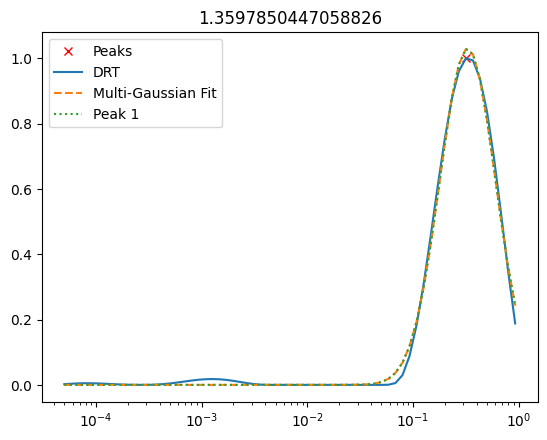

Normalization by  10.18992942644042
<class 'numpy.ndarray'>
[1.03364464 0.71969791 0.12082043]


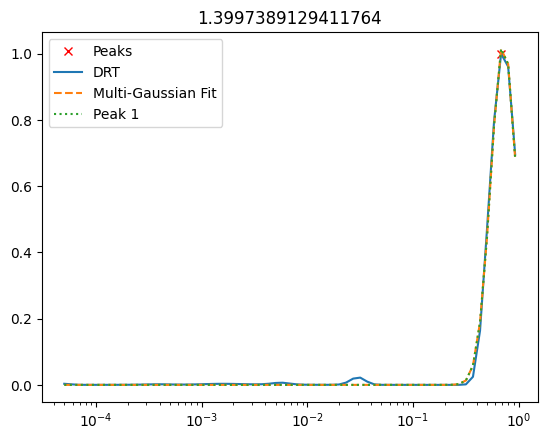

Normalization by  9.009256965150913
<class 'numpy.ndarray'>
[1.01754941 0.68045939 0.13122952]


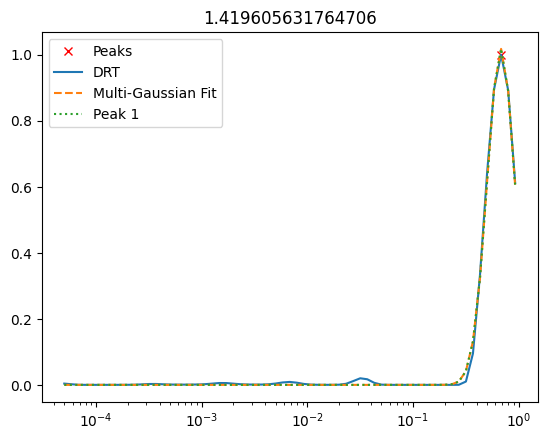

Normalization by  6.423760909146812
<class 'numpy.ndarray'>
[1.02062739 0.5957934  0.15705702]


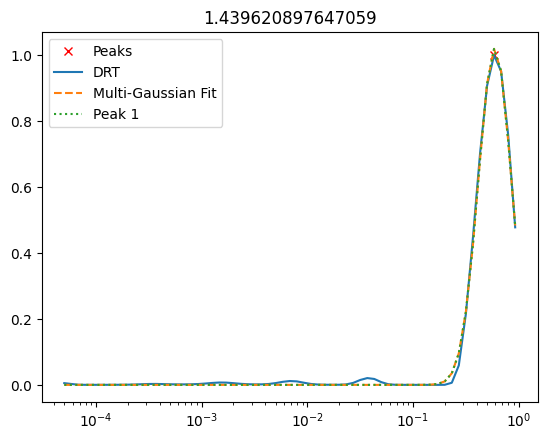

Normalization by  3.3053319971188384
<class 'numpy.ndarray'>
[1.02630507 0.41703352 0.21740898]


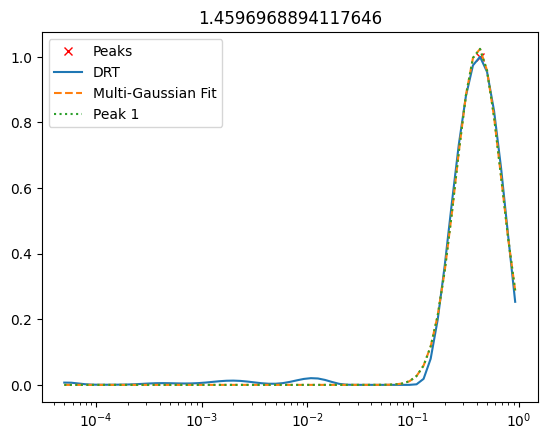

Normalization by  1.3759310408404168
<class 'numpy.ndarray'>
[3.07097467e-02 5.80177435e-04 3.40968146e-01 1.02822350e+00
 1.77591138e-01 3.71756034e-01]


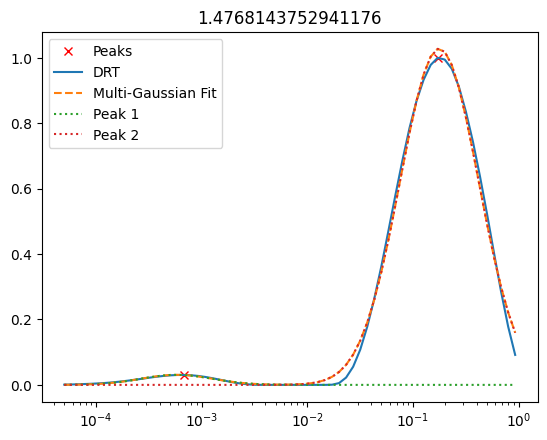

Normalization by  1.7841256845114462
<class 'numpy.ndarray'>
[0.02302454 0.00277891 0.45842869 1.04080602 0.11950026 0.13876109]


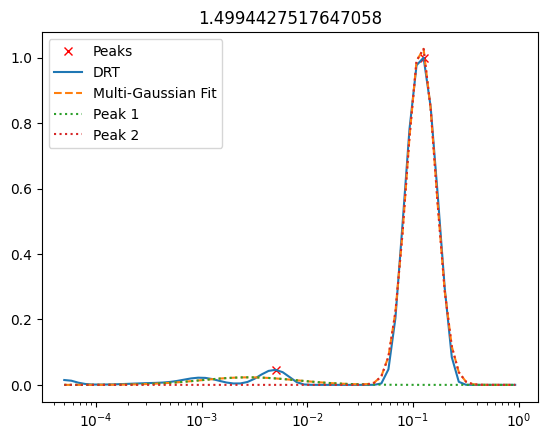

Normalization by  0.517764268004675
<class 'numpy.ndarray'>
[0.08936348 0.00165951 0.2896933  1.02597282 0.08100724 0.32204607]


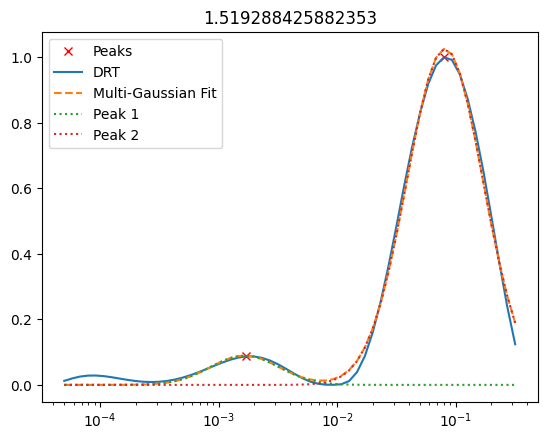

Normalization by  0.5657536152115794
<class 'numpy.ndarray'>
[5.24123319e-02 5.32514948e-04 2.00029077e-01 1.13661812e-01
 2.66736541e-03 1.56750630e-01 1.02954368e+00 3.55171360e-02
 1.56019828e-01]


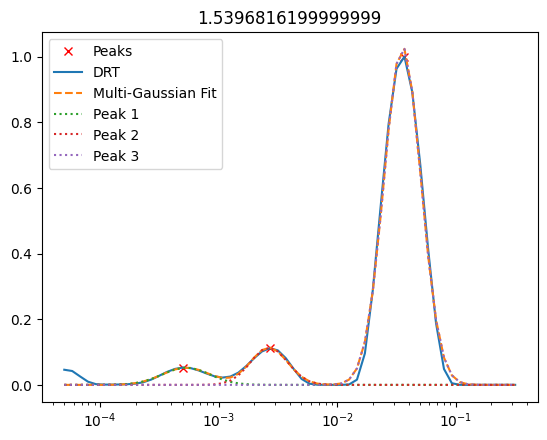

Normalization by  0.18227722178956876
<class 'numpy.ndarray'>
[1.03534106e-01 1.95284506e-04 3.06916218e-01 1.02548275e+00
 2.84195847e-02 5.25916605e-01]


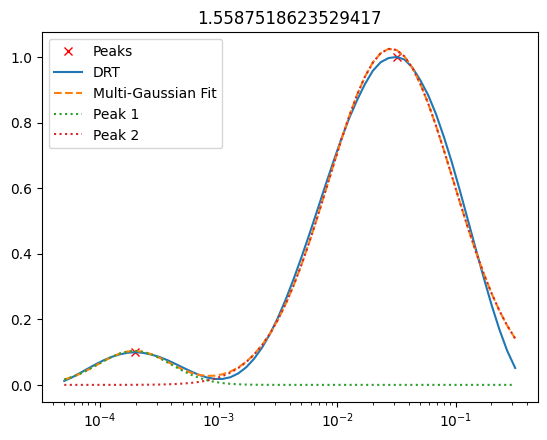

Normalization by  0.7997766047323984
<class 'numpy.ndarray'>
[8.87305914e-02 4.79502296e-04 8.71959696e-02 2.58228450e-01
 2.61438011e-03 6.40720786e-02 1.06793620e+00 2.11587479e-02
 6.62597342e-02]


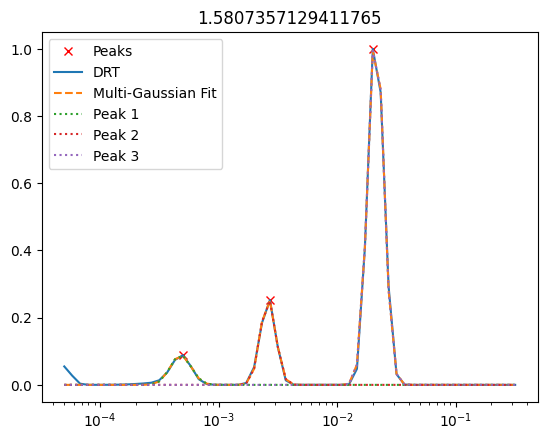

Normalization by  0.09393461269598809
<class 'numpy.ndarray'>
[0.09918793 0.0011511  0.74288148 0.96392977 0.00840091 0.54347982]


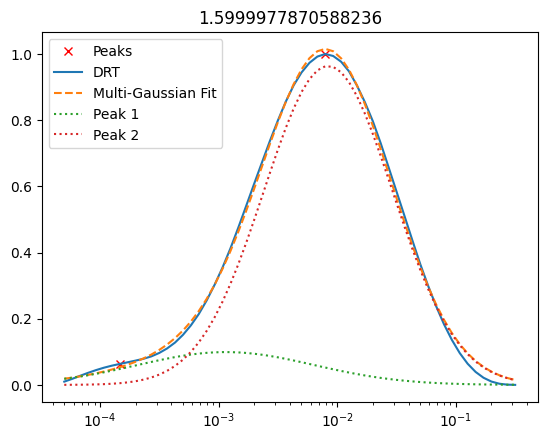

Normalization by  0.054535495118521043
<class 'numpy.ndarray'>
[3.74040032e-01 7.46765191e-04 5.36925541e-01 8.76071809e-01
 5.66167742e-03 5.90918944e-01]


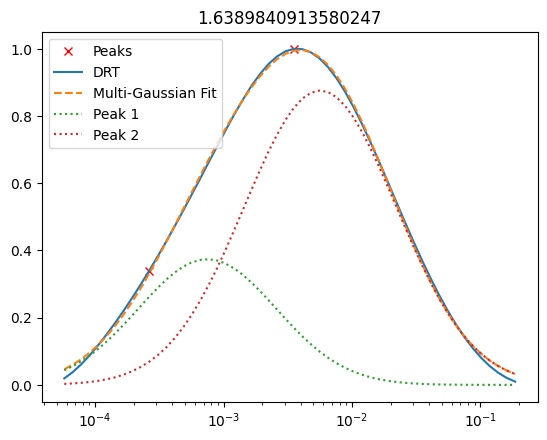

Normalization by  0.049647506055045594
<class 'numpy.ndarray'>
[0.64153844 0.00075477 0.51129159 0.73053804 0.00471743 0.46430786]


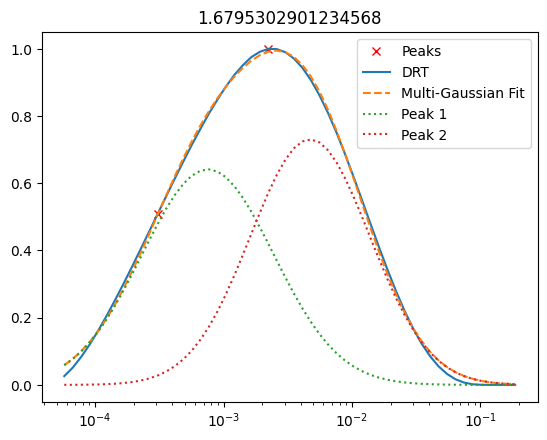

Normalization by  0.04272380199224922
<class 'numpy.ndarray'>
[1.03167856 0.00155264 0.72616528]


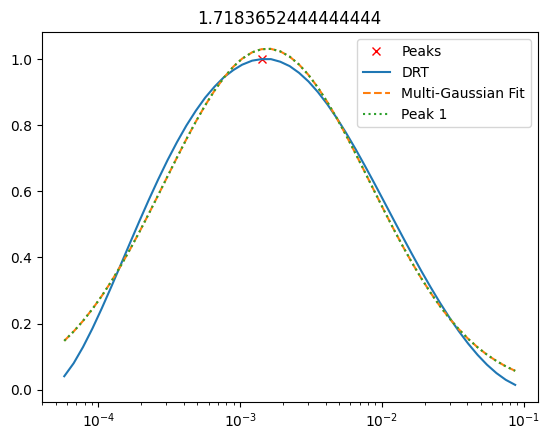

Normalization by  0.038021896067566355
<class 'numpy.ndarray'>
[1.02592956e+00 9.74046695e-04 7.13341315e-01]


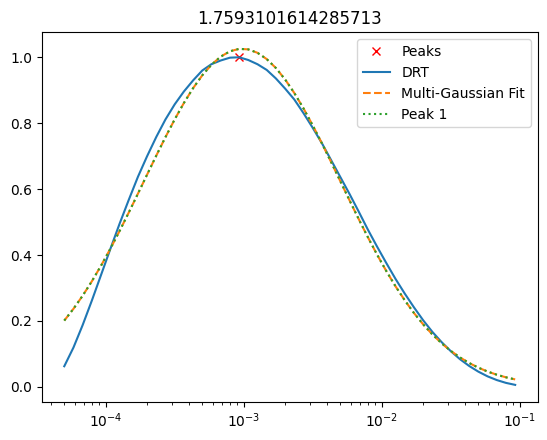

Normalization by  0.038426786496051975
<class 'numpy.ndarray'>
[8.00318625e-01 1.18894152e-03 6.14985539e-01 4.56338644e-01
 2.55651523e-04 3.78157168e-01]


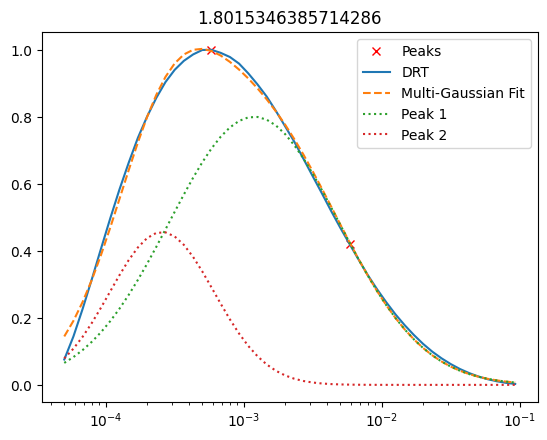

Normalization by  0.0408331459623385
<class 'numpy.ndarray'>
[7.96856203e-01 8.44603485e-04 5.40460147e-01 4.72879489e-01
 2.10477871e-04 3.39308799e-01]


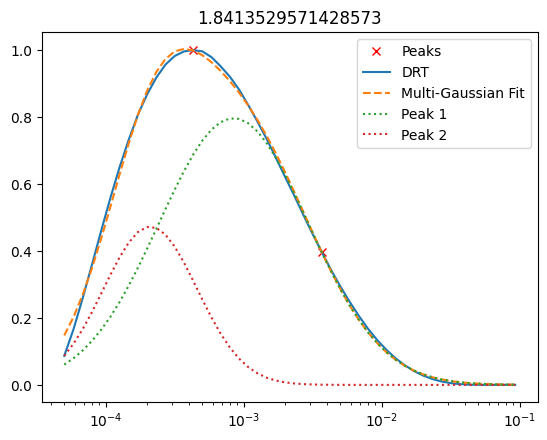

Normalization by  0.04340536500127251
<class 'numpy.ndarray'>
[6.85382102e-01 9.06729525e-04 5.69483444e-01 5.62336327e-01
 2.26901123e-04 3.61471038e-01]


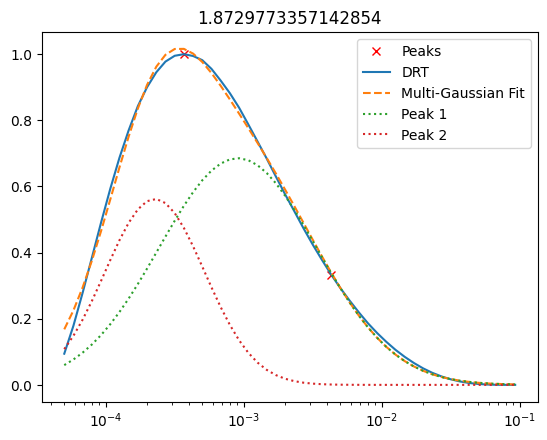

Normalization by  0.04686855214621599
<class 'numpy.ndarray'>
[7.56691191e-01 6.60970912e-04 5.04185773e-01 4.93914376e-01
 1.90303051e-04 3.20279581e-01]


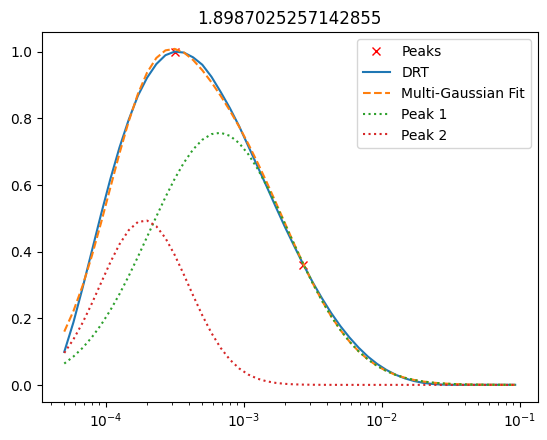

In [20]:
for file in mea['files'][0:1]:
    print(file)

    spectra, impedance, metadata = load_spectra_h5(file)
    # print(metadata)
    cmap = plt.get_cmap('rainbow')
    colors = cmap(np.linspace(0,1,len(spectra))) 

    # print(spectra[1])
    # print(metadata)

    # filename_REL = r'\\ELECTROLYZER\PEM-WE_measurements\2026\319_VII_VII Racek_2026_3, 14Ar1O2, GDE\PROCESSED_EIS\VII_Day1_procedure1_05_PEIS_C01_RELAXIS_DRT.txt'
    # data_REL = np.loadtxt(filename_REL,skiprows = 2)
    # print(spectra[0][:,1])
    
    results = []
    spectrum_id = 1 
    
    for i in range(0,20):
    # for i in range(0,len(spectra)):
        tau = spectra[i][:,0]
        gamma = spectra[i][:,1]/max(spectra[i][:,1])
        
        print('Normalization by ',max(spectra[i][:,1]))

        
        # Find peaks
        peak1, properties1 = find_peaks(gamma, height=0.9)

        for pk in peak1:
            # select a small window around the peak
            mask = (tau > 0.4*tau[pk]) & (tau < tau[pk]*2.5)
            popt, _ = curve_fit(gaussian_log, tau[mask], gamma[mask], 
                                p0=[gamma[pk], tau[pk], 0.1])
        # plt.plot(tau,   gamma-gaussian_log(tau, *popt))
        peaks, properties = find_peaks(gamma-gaussian_log(tau, *popt),  height=0.03,prominence = 0.01)
#         plt.plot(tau[peaks], gamma[peaks]-gaussian_log(tau, *popt)[peaks], 'rx', label="Peaks")
#         plt.xscale('log')
#         plt.show()
        
        
        print(type(peaks))
        peaks = np.append(peaks,peak1[0])
        # properties = np.append(properties,properties1[0])
        # properties.append(properties1[0])
        
        sigma_max = 1  # adjust based on your DRT resolution

        lower_bounds = []
        upper_bounds = []

        for pk in peaks:
            lower_bounds += [0, tau.min()/10, 0]           # A ≥ 0, tau ≥ min, sigma ≥ 0
            upper_bounds += [np.inf, 10*tau.max(), sigma_max]


        # Initial guess from peak detection
        initial_guess = []
        for pk in peaks:
            initial_guess += [gamma[pk], tau[pk], 0.5]  # amplitude, position, width

        # Fit
        try:
            popt, _ = curve_fit(multi_gaussian, tau, gamma, p0=initial_guess,bounds=(lower_bounds, upper_bounds))
        except:
            popt, _ = curve_fit(multi_gaussian, tau, gamma, p0=popt,bounds=(lower_bounds, upper_bounds))

        # Plot result

        print(popt)
        
        # Plot individual peaks
        for j in range(0, len(popt), 3):

            A = popt[j]
            tau0 = popt[j+1]
            sigma = popt[j+2]

            # Area under Gaussian in log-space (approximate)
            area = A * sigma *np.sqrt(2*np.pi) * np.log(10)

            results.append({
                "spectrum_id": i+1,
                "peak_id": j//3 ,
                "tau": tau0,
                "amplitude": A*max(spectra[i][:,1]),
                "sigma": sigma,
                "area": area*max(spectra[i][:,1]),
                "E (V)": metadata[i]['E (V)'],
                "I (mA)": metadata[i]['I (mA)'],
                "Ro (Ohm)": metadata[i]['Ro (Ohm)'],
                "L (H)": metadata[i]['L (H)'],
                'time' : int(np.floor(i/20)+1)
            })            

            
            
        plt.plot(tau[peaks], gamma[peaks], 'rx', label="Peaks")
        plt.plot(tau, gamma, label='DRT')
        plt.plot(tau, multi_gaussian(tau, *popt), '--', label='Multi-Gaussian Fit')
        for j in range(0, len(popt), 3):
            plt.plot(tau, popt[j]*np.exp(-((np.log10(tau)-np.log10(popt[j+1]))**2)/(2*popt[j+2]**2)),
                     ':', label=f'Peak {j//3+1}')
        plt.xscale('log')
        plt.title(metadata[i]['E (V)'])
        plt.legend()
        plt.show()         
        
#         # print(impedance[i][:,0])
#         gamma = spectra[i][:,1]
#         Z = drt_to_impedance(tau, multi_gaussian(tau, *popt)*max(spectra[i][:,1]), 1/tau, R_inf=metadata[i]['Ro (Ohm)'], L = metadata[i]['L (H)'])
#         plt.plot(impedance[i][:,0][15:],impedance[i][:,1][15:])
#         plt.plot(np.real(Z),-np.imag(Z))
#         # plt.plot
#         plt.show()

        
            

df = pd.DataFrame(results)
        
        
#         # Fit each peak individually
#         peak_params = []
#         for pk in peaks:
#             # select a small window around the peak
#             mask = (tau > tau[pk]/2) & (tau < tau[pk]*2)
#             popt, _ = curve_fit(gaussian_log, tau[mask], gamma[mask], 
#                                 p0=[gamma[pk], tau[pk], 0.1])
#             peak_params.append(popt)
#             print(f"Fitted peak: A={popt[0]:.3e}, τ0={popt[1]:.3e}, sigma={popt[2]:.3f}")

#         # Plot fits
#         # plt.plot(tau, gamma, label="Smoothed DRT")
#         fit_sum = np.zeros(len(tau))
#         for params in peak_params:
#             plt.plot(tau, gaussian_log(tau, *params), '--', label=f'Fit τ0={params[1]:.2e}')
#             fit_sum = fit_sum + gaussian_log(tau, *params)

#         plt.plot(tau, fit_sum, '-', label='Sum',c='black')
        
#         print(peaks, properties)
#         # plt.plot(data_REL[:,2*i],data_REL[:,2*i+1],'--',c=colors[i])
#         plt.xscale('log')
#         plt.show()
    
    
    
    

    # for i in range(0,len(spectra)):
    #     print(impedance[i])
    #     x = impedance[i][:,0]
    #     y = -impedance[i][:,1]
    #     plt.scatter(x,y,c=colors[i])
    #     # plt.xscale('log')
    # plt.show()
#     print(metadata[2]['Ro'])
#     for i in range(0,len(spectra)):
#         plt.plot(metadata[i]['E'],metadata[i]['Ro'],'x')
# plt.show()

In [14]:
import numpy as np

def assign_peak_ids_with_height(new_taus, new_heights,
                                ref_taus, ref_heights, ref_ids,
                                log_tau_tol=0.3, height_ratio_tol=0.5):

    ref_logtau = np.log10(ref_taus)
    assigned_ids = []
    used_ref = set()

    for tau, h in zip(new_taus, new_heights):
        logtau = np.log10(tau)
        distances = np.abs(ref_logtau - logtau)
        candidate_idxs = np.argsort(distances)

        assigned = None
        for idx in candidate_idxs:
            if idx in used_ref:
                continue
            if distances[idx] > log_tau_tol:
                break

            h_ref = ref_heights[idx]
            height_ratio = h / h_ref
            if (1 - height_ratio_tol) <= height_ratio <= (1 + height_ratio_tol):
                assigned = ref_ids[idx]
                used_ref.add(idx)
                break

        assigned_ids.append(assigned)

    return assigned_ids


In [15]:
import pandas as pd

df = df.copy()
df["assigned_peak_id"] = np.nan

# Sort spectra in reverse order (start from last)
spectrum_ids = sorted(df["spectrum_id"].unique(), reverse=True)

# Initialize reference from the last spectrum
ref_sid = spectrum_ids[0]
ref = df[df["spectrum_id"] == ref_sid].copy()
ref["assigned_peak_id"] = ref["peak_id"]

df.loc[ref.index, "assigned_peak_id"] = ref["assigned_peak_id"]

next_new_id = df["peak_id"].max() + 1

# Loop over remaining spectra
for sid in spectrum_ids[1:]:
    current = df[df["spectrum_id"] == sid].copy()

    assigned = assign_peak_ids_with_height(
        current["tau"].values,
        current["amplitude"].values,
        ref["tau"].values,
        ref["amplitude"].values,
        ref["assigned_peak_id"].values,
        log_tau_tol=0.7,
        height_ratio_tol=1
    )

    # Assign matched or new IDs
    new_ids = []
    for pid in assigned:
        if pid is None:
            new_ids.append(next_new_id)
            next_new_id += 1
        else:
            new_ids.append(pid)

    current["assigned_peak_id"] = new_ids
    df.loc[current.index, "assigned_peak_id"] = current["assigned_peak_id"]

    # Update reference to this spectrum
    ref = current.copy()


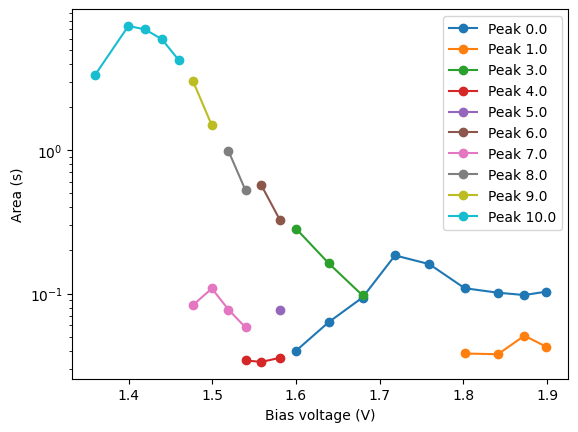

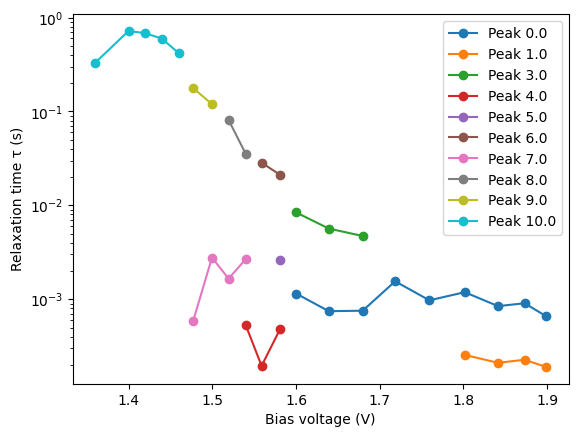

In [16]:
for pid, group in df.groupby("assigned_peak_id"):
    plt.plot(group["E (V)"], group["area"], 'o-', label=f"Peak {pid}")

plt.yscale("log")
plt.xlabel("Bias voltage (V)")
plt.ylabel("Area (s)")
plt.legend()
plt.show()

for pid, group in df.groupby("assigned_peak_id"):
    plt.plot(group["E (V)"], group["tau"], 'o-', label=f"Peak {pid}")

plt.yscale("log")
plt.xlabel("Bias voltage (V)")
plt.ylabel("Relaxation time τ (s)")
plt.legend()
plt.show()


In [356]:
print(np.array([df[df['assigned_peak_id'] == 2]['E (V)'],
                df[df['assigned_peak_id'] == 2]['amplitude'],
                df[df['assigned_peak_id'] == 2]['sigma'],
               df[df['assigned_peak_id'] == 2]['area']]).T)

# print(np.array([df[df['assigned_peak_id'] == 2]['E (V)'],df[df['assigned_peak_id'] == 2]['tau']]).T)

[[1.35961044e+00 2.95858021e-01 4.95903504e-01 8.46810332e-01]
 [1.39959125e+00 3.86239502e-01 4.78705900e-01 1.06716382e+00]
 [1.41962954e+00 5.35252359e-01 5.63203439e-01 1.73992093e+00]
 [1.43964238e+00 2.92995193e-01 3.42020906e-01 5.78387329e-01]
 [1.45961300e+00 2.85460365e-01 3.57161779e-01 5.88459282e-01]
 [1.47964475e+00 1.84753994e-01 3.29543180e-01 3.51408116e-01]
 [1.49960964e+00 1.08583066e-01 3.10028900e-01 1.94298704e-01]
 [1.51962620e+00 6.07773435e-02 3.26787828e-01 1.14633937e-01]
 [1.53958508e+00 3.55178451e-02 3.71377693e-01 7.61321415e-02]
 [1.55959219e+00 2.22004557e-02 3.80387893e-01 4.87409734e-02]
 [1.57958955e+00 1.23410521e-02 3.74382212e-01 2.66669296e-02]
 [1.59960986e+00 1.21482179e-02 4.19184520e-01 2.93916139e-02]
 [1.63960716e+00 7.31110346e-03 3.91080515e-01 1.65026896e-02]
 [1.67962121e+00 4.48526176e-03 2.95430802e-01 7.64802310e-03]
 [1.71959508e+00 3.62167120e-03 2.22717112e-01 4.65552035e-03]
 [1.75958291e+00 2.73643015e-03 1.97668193e-01 3.121956

62.423770389765295


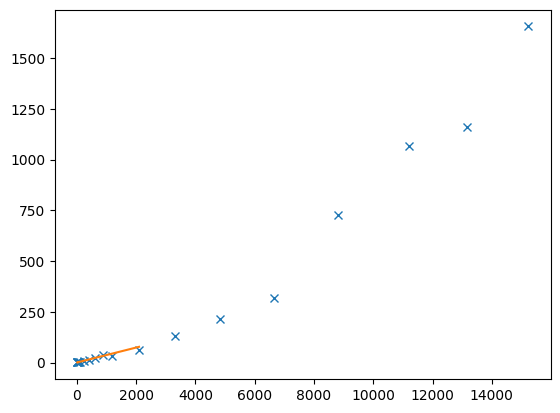

In [361]:
x = df[df['assigned_peak_id'] == 2]['I (mA)']
y = 1/df[df['assigned_peak_id'] == 2]['area']
plt.plot(x,y,'x')
k,q = np.polyfit(x[:8],y[:8],1)
plt.plot(x[:13],k*x[:13]+q)
print(2.3/k)

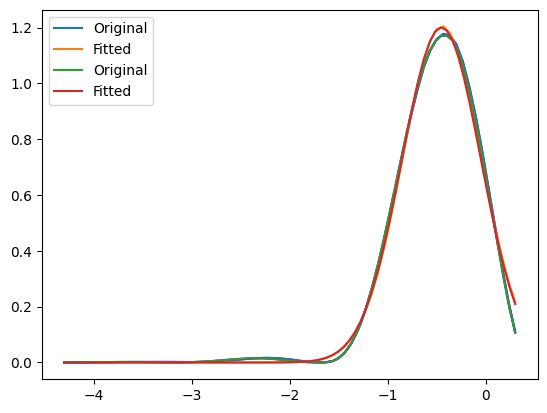

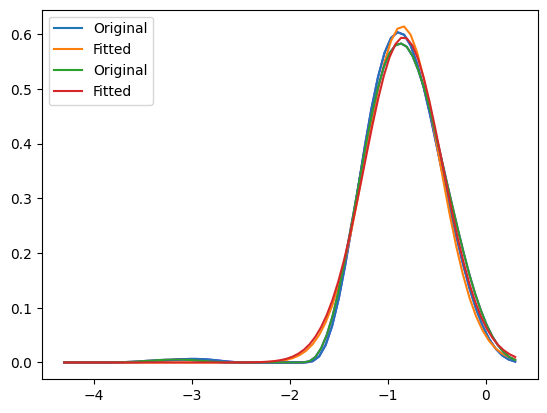

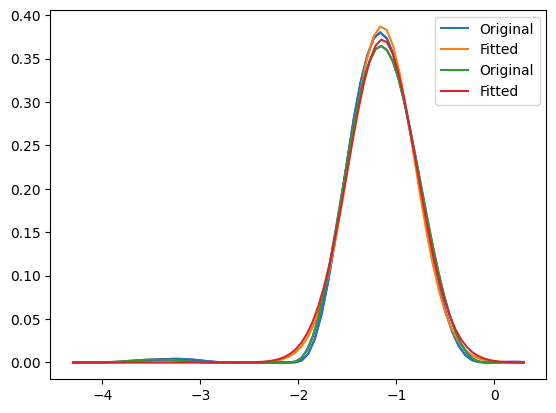

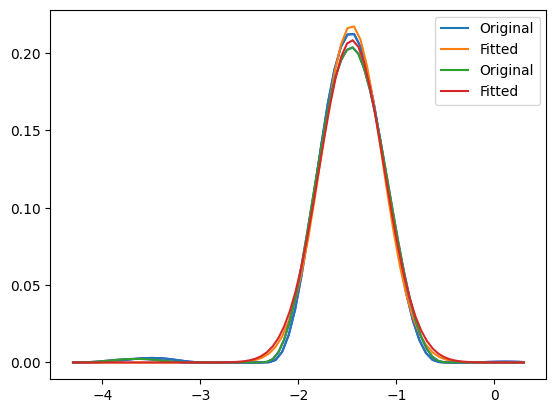

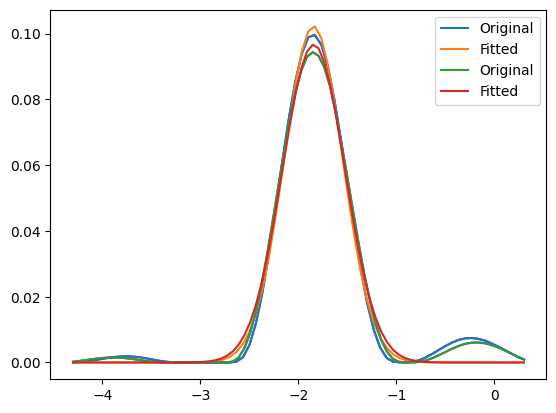

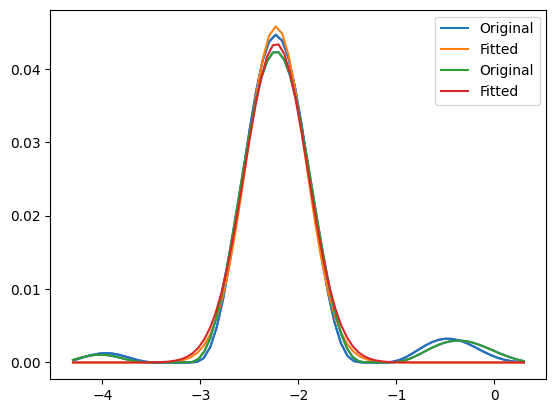

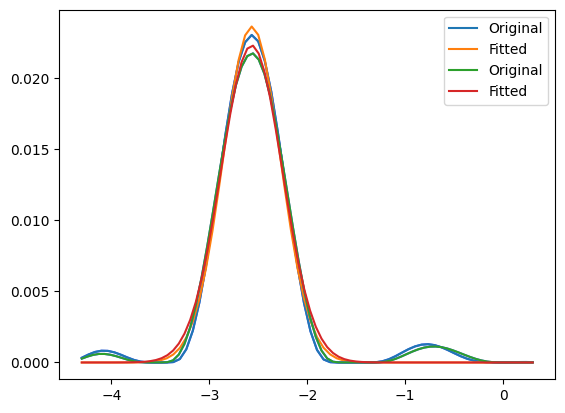

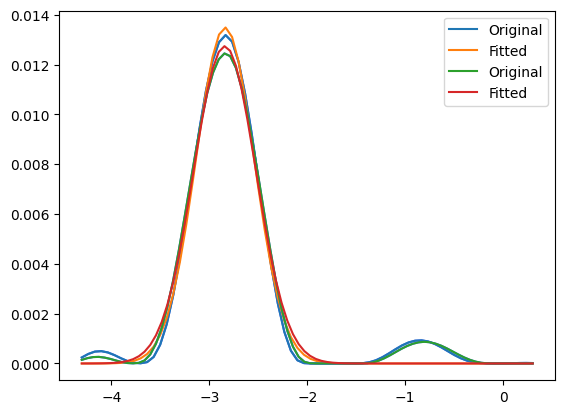

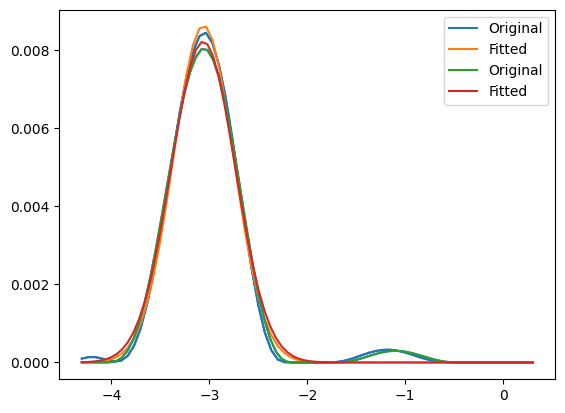

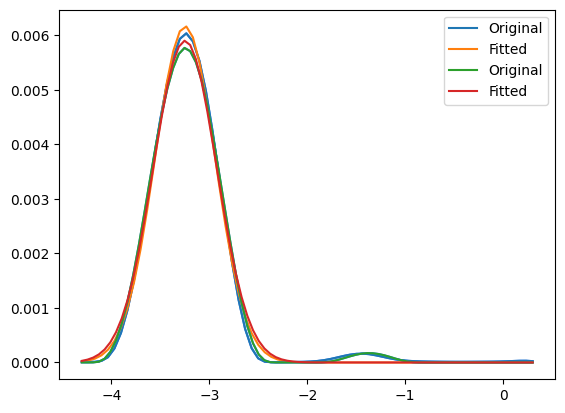

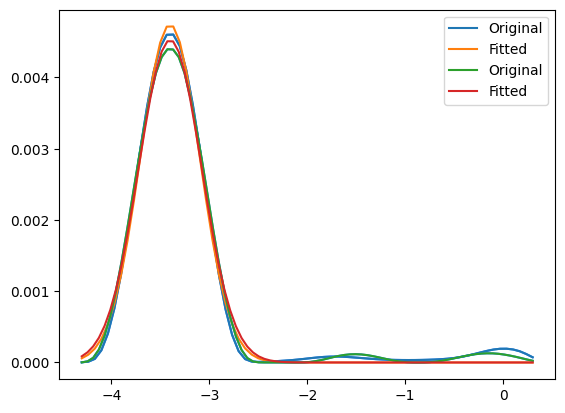

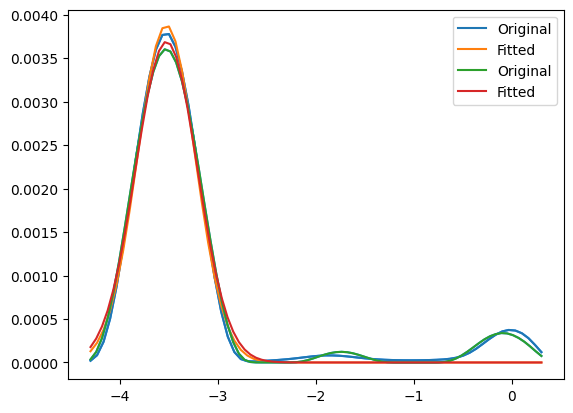

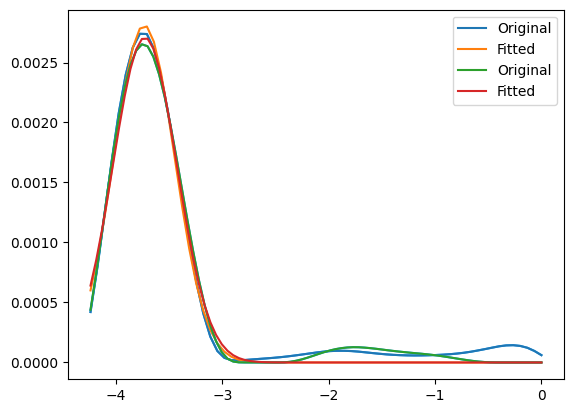

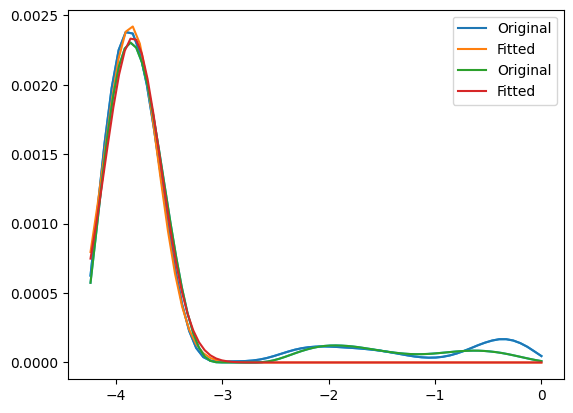

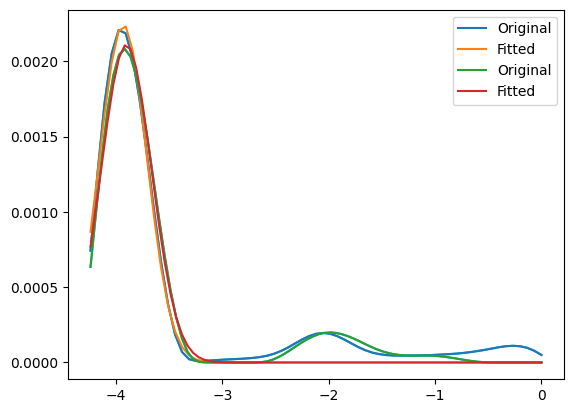

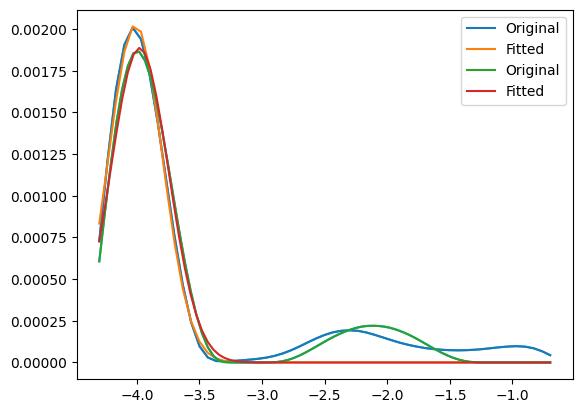

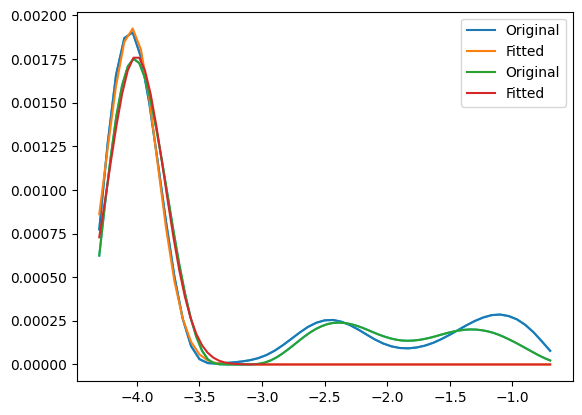

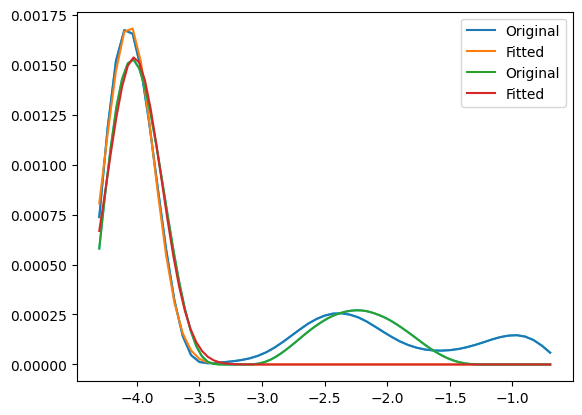

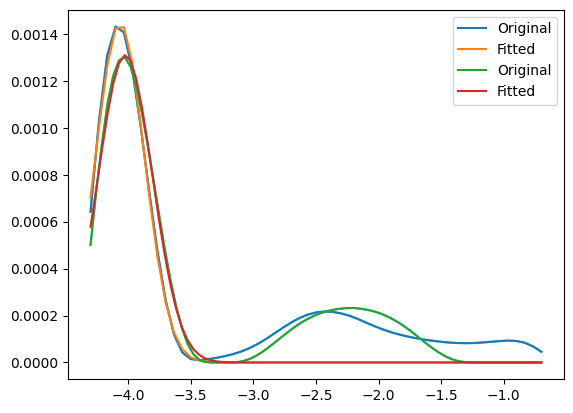

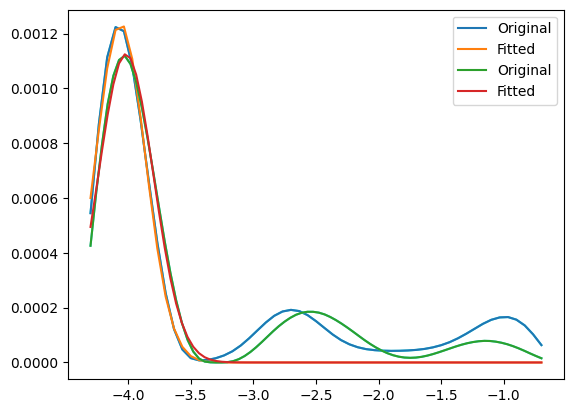

In [37]:
from scipy.optimize import curve_fit

def func(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))
p0 = [1,1,1]
params = []
params_REL = []
for i in range(0,len(spectra)-40):
    x = np.log10(spectra[i][:,0])
    y = spectra[i][:,1]
    plt.plot(x,y,c=colors[i])

    # plt.xscale('log')
    
    
    # x = np.log10(mea['tau'][idx])
    
    popt, _ = curve_fit(func, x, y,p0)
    ym = func(x, *popt)
    p0=popt
    plt.plot(x, y, label='Original')

    plt.plot(x, ym, label='Fitted')
    
    params.append(popt)
    
    x = np.log10(data_REL[:,2*i])
    y = data_REL[:,2*i+1]
    plt.plot(x,y,c=colors[i])

    # plt.xscale('log')
    
    
    # x = np.log10(mea['tau'][idx])
    
    popt, _ = curve_fit(func, x, y,p0)
    ym = func(x, *popt)
    p0=popt
    plt.plot(x, y, label='Original')

    plt.plot(x, ym, label='Fitted')
    
    params_REL.append(popt)    
 
    
    plt.legend()
    plt.show()
#     params.append(list(popt))
    
#     plt.show()


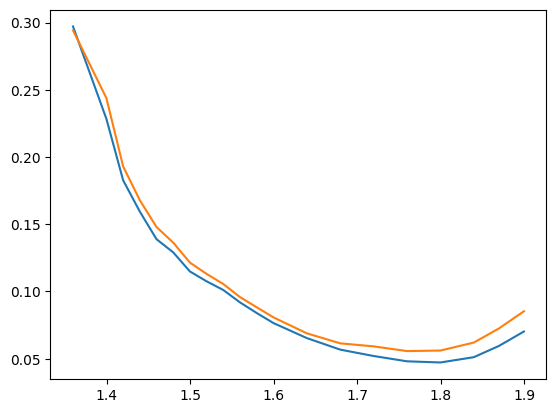

In [34]:
params = np.array(params)
params_REL = np.array(params_REL)
E = []
I = []
for i in range(0,20):
    E.append(metadata[i]['E'])
    I.append(metadata[i]['I'])
plt.plot(E,10**params[:,1]/params[:,0])
plt.plot(E,10**params_REL[:,1]/params_REL[:,0])